In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [38]:
df = pd.read_csv("../data/fitness_data_raw.csv")

df.head()

,timestamp,heart_rate_bpm,steps,sleeping,spo2_pct,calories_burned,hour,day_of_week,is_weekend,is_anomaly,anomaly_type
0,2024-01-01 00:00:00,62.3,0,1,97.4,3.32,0.0,0.0,0.0,0.0,normal
1,2024-01-01 00:05:00,65.1,0,1,97.9,2.98,0.0,0.0,0.0,0.0,normal
2,2024-01-01 00:10:00,58.1,0,1,96.5,2.09,0.0,0.0,0.0,0.0,normal
3,2024-01-01 00:15:00,54.0,0,1,96.8,3.45,0.0,0.0,0.0,0.0,normal
4,2024-01-01 00:20:00,56.4,0,1,97.6,2.22,0.0,0.0,0.0,0.0,normal


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17281 entries, 0 to 17280
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        17281 non-null  object 
 1   heart_rate_bpm   17281 non-null  object 
 2   steps            17281 non-null  object 
 3   sleeping         17281 non-null  int64  
 4   spo2_pct         17281 non-null  float64
 5   calories_burned  17281 non-null  float64
 6   hour             17280 non-null  float64
 7   day_of_week      17280 non-null  float64
 8   is_weekend       17280 non-null  float64
 9   is_anomaly       17280 non-null  float64
 10  anomaly_type     17280 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


In [40]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed', errors='coerce')

df.set_index('timestamp', inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17281 entries, 2024-01-01 00:00:00 to 2026-03-17 00:00:00
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   heart_rate_bpm   17281 non-null  object 
 1   steps            17281 non-null  object 
 2   sleeping         17281 non-null  int64  
 3   spo2_pct         17281 non-null  float64
 4   calories_burned  17281 non-null  float64
 5   hour             17280 non-null  float64
 6   day_of_week      17280 non-null  float64
 7   is_weekend       17280 non-null  float64
 8   is_anomaly       17280 non-null  float64
 9   anomaly_type     17280 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 1.5+ MB


In [52]:
df.isnull().sum()


heart_rate_bpm     0
steps              0
sleeping           0
spo2_pct           0
calories_burned    0
hour               1
day_of_week        1
is_weekend         1
is_anomaly         1
anomaly_type       1
dtype: int64

In [54]:
df_hourly = df_hourly.reset_index()

In [53]:
# Fix index
df_hourly['timestamp'] = pd.to_datetime(df_hourly['timestamp'])
df_hourly.set_index('timestamp', inplace=True)

# Filter properly
df_hourly = df_hourly[df_hourly.index < "2025-01-01"]

In [42]:
print((df.isnull().sum() / len(df)) * 100)

heart_rate_bpm     0.000000
steps              0.000000
sleeping           0.000000
spo2_pct           0.000000
calories_burned    0.000000
hour               0.005787
day_of_week        0.005787
is_weekend         0.005787
is_anomaly         0.005787
anomaly_type       0.005787
dtype: float64


In [43]:
df['heart_rate_bpm'] = pd.to_numeric(df['heart_rate_bpm'], errors='coerce')
df['steps'] = pd.to_numeric(df['steps'], errors='coerce')

df['heart_rate_bpm'] = df['heart_rate_bpm'].interpolate()
df['steps'] = df['steps'].interpolate()

In [44]:
df.isnull().sum()

heart_rate_bpm     0
steps              0
sleeping           0
spo2_pct           0
calories_burned    0
hour               1
day_of_week        1
is_weekend         1
is_anomaly         1
anomaly_type       1
dtype: int64

In [45]:
df.shape

(17281, 10)

In [56]:
from scipy import stats

# Z-score calculation
df_hourly['z_score'] = stats.zscore(df_hourly['heart_rate_bpm'])

# Create anomaly column
df_hourly['anomaly'] = df_hourly['z_score'].abs() > 2

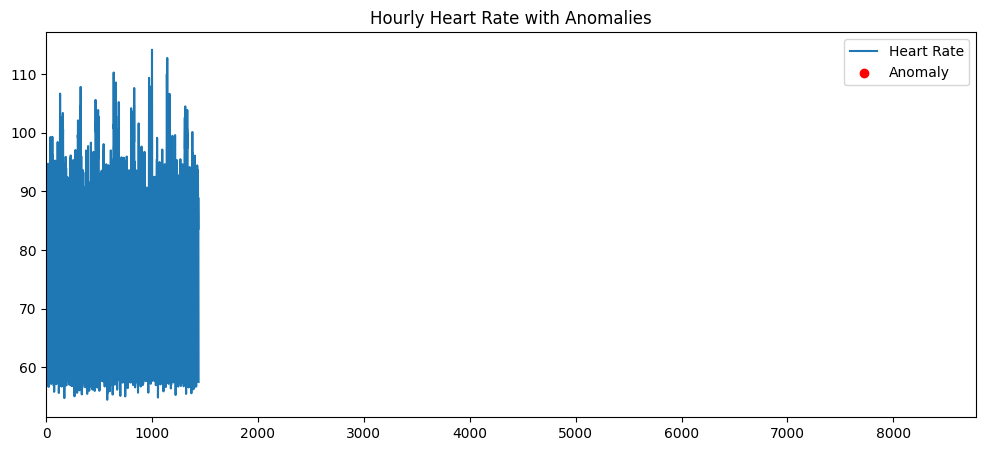

In [57]:
plt.figure(figsize=(12,5))

plt.plot(df_hourly.index, df_hourly['heart_rate_bpm'], label='Heart Rate')

plt.scatter(
    df_hourly[df_hourly['anomaly']].index,
    df_hourly[df_hourly['anomaly']]['heart_rate_bpm'],
    color='red',
    label='Anomaly'
)

plt.xlim(df_hourly.index.min(), df_hourly.index.max())

plt.legend()
plt.title("Hourly Heart Rate with Anomalies")

plt.show()

In [47]:
df_numeric = df.select_dtypes(include=['number'])

df_hourly = df_numeric.resample('h').mean()

In [48]:
print("Original rows:", len(df))
print("Hourly rows:", len(df_hourly))

Original rows: 17281
Hourly rows: 19345


In [29]:
df_hourly['hr_rolling_mean'] = df_hourly['heart_rate_bpm'].rolling(window=24).mean()

In [30]:
df_hourly['z_score'] = stats.zscore(df_hourly['heart_rate_bpm'])

df_hourly['anomaly'] = df_hourly['z_score'].abs() > 2

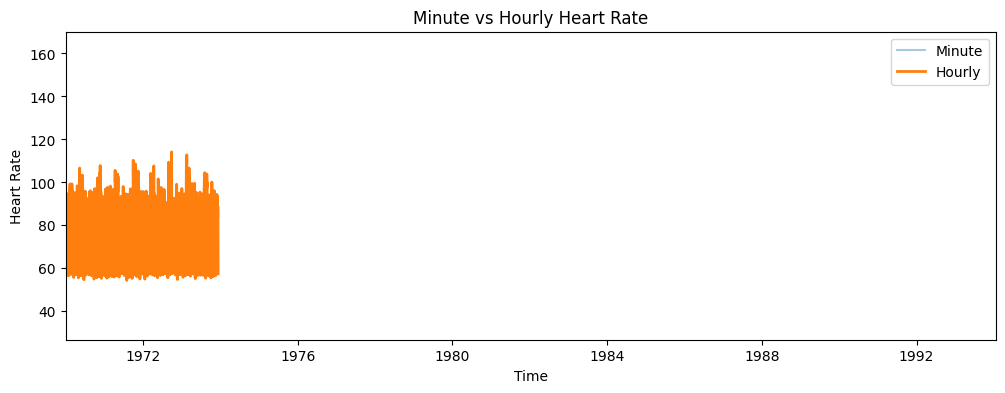

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(df.index, df['heart_rate_bpm'], alpha=0.4, label='Minute')
plt.plot(df_hourly.index, df_hourly['heart_rate_bpm'], linewidth=2, label='Hourly')

plt.legend()
plt.title("Minute vs Hourly Heart Rate")
plt.xlabel("Time")
plt.ylabel("Heart Rate")

plt.xlim(df_hourly.index.min(), df_hourly.index.max())  # 🔥 IMPORTANT

plt.show()

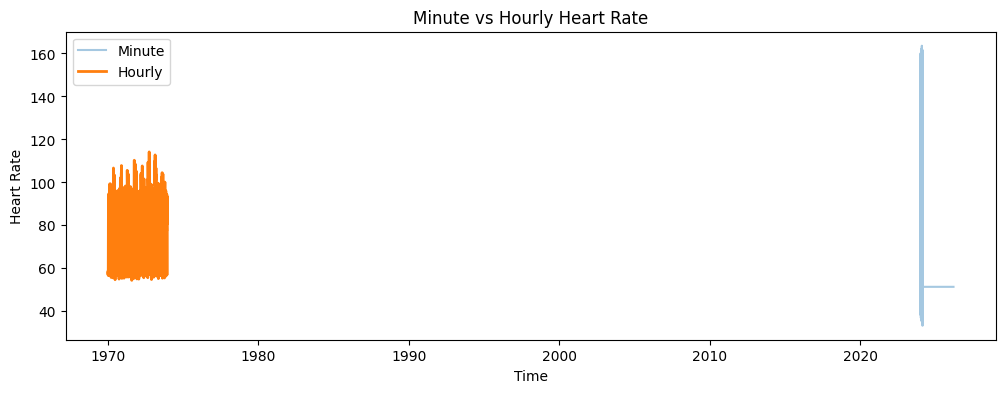

In [59]:
plt.figure(figsize=(12,4))

plt.plot(df.index, df['heart_rate_bpm'], alpha=0.4, label='Minute')
plt.plot(df_hourly.index, df_hourly['heart_rate_bpm'], linewidth=2, label='Hourly')

plt.legend()
plt.title("Minute vs Hourly Heart Rate")

plt.xlabel("Time")
plt.ylabel("Heart Rate")

plt.show()

In [33]:
df_hourly['anomaly'].value_counts()

anomaly
False    19345
Name: count, dtype: int64

In [34]:
df_hourly.reset_index(inplace=True)

df_hourly.to_csv("../outputs/processed_data.csv", index=False)